# Mini VLA Simulator
ML toolkit (CNNs,
cross-entropy, train/val splits, ablation studies) applied to a toy robotics problem. Today's real VLA models are trained: collect
demonstrations, then do supervised imitation learning on `(image, instruction) -> action`.

In [1]:
!pip install -q gymnasium pillow matplotlib torch numpy pandas

In [2]:
import random
import hashlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn #pytorch's neural net
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from PIL import Image, ImageDraw
from IPython.display import Image as IPyImage, display

import gymnasium as gym
from gymnasium import spaces

def set_seed(seed=0):
    """making randomness reproducible for numpy, python, pytorch"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device: ", device)

device:  cuda


## 1. Environment — `MiniCartPoleVisionEnv` 

a 64×64 RGB image in, a discrete `{0: left, 1: right}` action out, the
internal dynamics are now the actual coupled cart-pole equations used by Gymnasium's
`CartPole-v1` (Barto, Sutton & Anderson, 1983), instead of an action-independent random walk:

$$\text{temp} = \frac{F + m_p \ell \dot\theta^2 \sin\theta}{m_c+m_p}
\qquad\qquad
\ddot\theta = \frac{g\sin\theta - \cos\theta \cdot \text{temp}}{\ell\left(\tfrac{4}{3} - \tfrac{m_p \cos^2\theta}{m_c+m_p}\right)}$$

Now the force applied to the cart genuinely changes how the pole rotates — the environment is
actually *controllable*, which is a prerequisite for anything to be learnable from it. An episode
ends when the cart leaves `|x| > 2.4` or the pole tips past `|θ| > 12°`, and reward is `+1` per step survived, the classic CartPole convention.

In [3]:
class MiniCartPoleVisionEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array"]}
    
    def __init__(self, max_steps=200):
        super().__init__()
        self.observation_space = spaces.Box(0,255,(64,64,3), dtype=np.uint8)
        self.action_space = spaces.Discrete(2) #0=push left, 1=push right

        #cartpole physical constants(gymnasium, Barto&Sutton)
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole =0.1
        self.totalMass=self.masscart + self.masspole
        self.length=0.5 #half of the pole's lenght
        self.polemass_length = self.masspole * self.length
        self.force_mag=10.0
        self.tau= 0.02 #seconds per simulation step

        self.x_threshold=2.4
        self.theta_threshold=12*2*np.pi/360 #12 degrees 
        self.max_steps=max_steps

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.x,self.x_dot,self.theta,self.theta_dot = self.np_random.uniform(-0.05,0.05,size=4)
        self.steps=0
        return self._render(),{}

    def step(self,action):
        force=self.force_mag if action == 1 else -self.force_mag
        costheta, sintheta = np.cos(self.theta), np.sin(self.theta)
        temp = (force + self.polemass_length * self.theta_dot**2 * sintheta)/self.totalMass
        theta_acc = (self.gravity *sintheta - costheta*temp)/(self.length*(4.0/3.0 - self.masspole* costheta**2 / self.totalMass))
        x_acc = temp -self.polemass_length * theta_acc * costheta/self.totalMass

        #semi-implicit euler's integration
        self.x_dot += self. tau * x_acc
        self.x += self.tau * self.x_dot
        self.theta_dot += self.tau *theta_acc
        self.theta +=self.tau *self.theta_dot
        self.steps +=1

        terminated =bool(abs(self.x)>self.x_threshold or abs(self.theta)>self.theta_threshold)
        truncated = self.steps>= self.max_steps
        reward=1.0 #+1 for every step the pole stays up

        return self._render(),reward, terminated,truncated,{}

    def _render(self):
        img=Image.new("RGB", (64,64), "black")
        d=ImageDraw.Draw(img)
        cx=32 +self.x*10 #world x -> pixel x
        d.rectangle([cx-8,45,cx+8,55], fill="yellow") #cart
        px,py = cx+35 * np.sin(self.theta),45 -35 *np.cos(self.theta)
        d.line([cx,45,px,py], fill ="blue", width =3) #pole(lever arm exaggerated for visibility)
        return np.array(img, dtype=np.uint8)
        

obs shape: (64, 64, 3) uint8


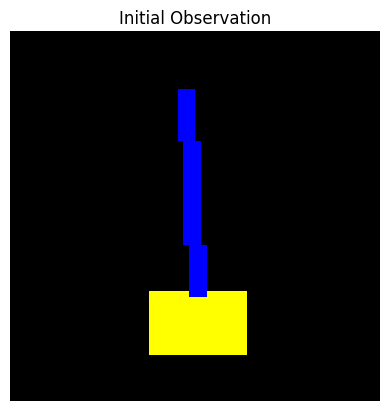

In [4]:
env = MiniCartPoleVisionEnv()
obs, _ = env. reset(seed=0)
print("obs shape:", obs.shape, obs.dtype)
plt.imshow(obs); plt.axis("off"); plt.title("Initial Observation"); plt.show()

# Language Encoder
no vocabulary, no tokenizer
* hash every word into of `size` buckets, count collisions and all..
* built on `hashlib.md5` instead of Python's built-in `hash()`.
* firstly,`hash()` was randomized per interpreter process for strings(`PYTHONHASHSEED`), so the same instruction hashed to different buckets every time the kernel restarted, which broke any saved checkpoints, SO THAT IS AVOIDED.
* `hashlib` gives the same bucket for the same word, every time, on every machine 

In [5]:
def stable_hash(word,size):
    #deterministic hash -> bucket index
    digest = hashlib.md5(word.encode("utf-8")).hexdigest()
    return int(digest,16)%size

def bow_vector(text, size=1000):
    """text -> fized sized hashed word count vector"""
    vec = np.zeros(size, dtype=np.float32)
    for word in text.lower().split():
        vec[stable_hash(word,size)]+=1.0
    return vec

bow=bow_vector("keep the pole upright")
print("bow vector:", bow.shape, "| nonzero buckets", np.nonzero(bow)[0])

bow vector: (1000,) | nonzero buckets [347 479 811 828]


# Vision Encoder
* two stride-2 convolutions (`64*64*3 -> 32*32*16 -> 16*16*32 -> flatten -> 8192`)
* a `BatchNorm2d` after each conv.
    Batch Normalization stabilizes and speeds up traininh.


> 64 is height, 64 is width, 3 is RGB channels, 16*16*32=8192

In [6]:
def to_tensor_single(obs):
    """HWC uint8[0,255] to CHW float 32 [0,1], no batch dim(used inside the dataset)"""
    return torch.from_numpy(obs.copy()).float().permute(2,0,1)/255.0

def to_tensor_batch(obs):
    """HWC uint8[0,255] to NCHW float 32 [0,1], with a batch dim(for single-image inference)."""
    return to_tensor_single(obs).unsqueeze(0)

class VisionEncoder(nn.Module):
    """64x64x3 image -> 8192-d feature vector."""
    def __init__(self):
        super().__init__() #for initializing the parent class """nn.Module"""
        self.conv1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
    def forward(self,x):
        # Input:  (B, 3, 64, 64)
    # Output: (B, 16, 32, 32)
        x= torch.relu(self.bn1(self.conv1(x)))
        
        # Input:  (B, 16, 32, 32)
    # Output: (B, 32, 16, 16)
        x=torch.relu(self.bn2(self.conv2(x)))
        return x.flatten(1)
        # flatten dimensions 1 onward while preserving batch dimension.
    # (B, 32, 16, 16) to (B, 32×16×16) to (B, 8192)

vision_encoder = VisionEncoder()
v= vision_encoder(to_tensor_batch(obs))
print("vision vector; ", v.shape) #expect(1,8192)

vision vector;  torch.Size([1, 8192])


# First Convolution

The first convolutional layer extracts basic visual features from the input image, such as edges, corners, textures, and simple shapes.

## Convolution Layer

```python
self.conv1 = nn.Conv2d(
    3,          # input channels
    16,         # output channels
    3,          # kernel size
    stride=2,
    padding=1
)
```

Mathematically:

$$
\text{Conv2d}(C_{in}, C_{out}, K, S, P)
$$

where:

- $C_{in} = 3$: number of input channels
- $C_{out} = 16$: number of output feature maps
- $K = 3$: kernel size $3 \times 3$
- $S = 2$: stride
- $P = 1$: padding

---

##  Input Channels: `3`

The input image is an RGB image, so it has **3 channels**:

- Red
- Green
- Blue

Therefore, the input image has the spatial shape:

$$
64 \times 64
$$

with 3 channels:

$$
64 \times 64 \times 3
$$

In PyTorch's tensor format, the shape is written as:

$$
[\text{batch\_size}, 3, 64, 64]
$$

---

##  Output Channels: `16`

The layer produces **16 output channels**, also called **feature maps**.

This means the network learns **16 different filters**, where each filter can learn to detect a different visual pattern.

For example, different filters may learn to respond to:

- edges
- corners
- textures
- simple shapes

Thus:

$$
3\text{ input channels}
\rightarrow
16\text{ learned feature maps}
$$

The output therefore contains 16 feature maps.

---

## Kernel Size: `3`

The convolution uses a:

$$
3 \times 3
$$

kernel.

Conceptually:

$$
\begin{bmatrix}
x & x & x \\
x & x & x \\
x & x & x
\end{bmatrix}
$$

A kernel is a small matrix of **learnable weights**.

Since there are 16 output channels, the layer learns **16 different filters**.

Each filter scans the input image and produces one corresponding feature map.

---

## Stride: `2`

The **stride** determines how far the kernel moves after each operation.

With:

```python
stride=2
```

the kernel moves **2 pixels at a time** rather than 1.

This reduces the spatial dimensions of the image.

Conceptually:

$$
64 \times 64
\rightarrow
32 \times 32
$$

Therefore, stride $=2$ performs a form of spatial downsampling while extracting features.

---

## Padding: `1`

With:

```python
padding=1
```

one layer of padding is added around the border of the input.

This helps control the output dimensions and allows the convolution to process pixels near the image boundaries more effectively.

For a $3 \times 3$ kernel:

$$
P = 1
$$

means one pixel of padding is added on each side.

---

##  Output Size Calculation

For a convolution layer, the output spatial dimension is:

$$
H_{out}
=
\left\lfloor
\frac{H_{in}+2P-K}{S}
\right\rfloor+1
$$

For this layer:

$$
H_{in}=64,\quad
P=1,\quad
K=3,\quad
S=2
$$

Therefore:

$$
H_{out}
=
\left\lfloor
\frac{64+2(1)-3}{2}
\right\rfloor+1
$$

$$
=
\left\lfloor
\frac{63}{2}
\right\rfloor+1
$$

$$
=31+1
$$

$$
=32
$$

The same calculation applies to the width:

$$
W_{out}=32
$$

---

## Final Transformation

The complete transformation is:

$$
64 \times 64 \times 3
$$

$$
\downarrow
$$

**Conv2D**

$$
\text{Kernel}=3\times3
$$

$$
\text{Stride}=2
$$

$$
\text{Padding}=1
$$

$$
\text{Filters}=16
$$

$$
\downarrow
$$

$$32 \times 32 \times 16
$$

---

## PyTorch Tensor Representation

### Input

$$
[\text{batch\_size}, 3, 64, 64]
$$

### Layer

```python
nn.Conv2d(
    3,
    16,
    kernel_size=3,
    stride=2,
    padding=1
)
```

### Output

$$
[\text{batch\_size}, 16, 32, 32]
$$

So, in simple image notation:

$$
\boxed{64 \times 64 \times 3
\rightarrow
32 \times 32 \times 16}
$$



> The first convolution takes a 64×64 RGB image and transforms it into 16 learned feature maps, while reducing the spatial resolution from 64×64 to 32×32.


# 4. Instructions & Scripted Experts

For language to matter, different instructions must require *different* actions given the *same*
observation. We define three instructions, each with its own scripted "expert" controller that
will generate training demonstrations later

| Instruction | Expert behavior |
|---|---|
| `"balance the pole"` | Bang-bang controller: push toward the direction the pole is leaning / rotating (`θ + 0.5·θ̇ > 0 → right`) |
| `"push the cart right"` | Always push right, ignoring the pole entirely |
| `"push the cart left"` | Always push left, ignoring the pole entirely |

Only the first expert actually solves the balancing problem. The other two are pure
**instruction-following** tasks: a model could in principle solve them from language alone,
without even looking at the image.
`NOTE:` Mixing both kinds of task on purpose is what will let us test..
later.. whether the trained model is really using *both* modalities.

In [7]:
def expert_action(theta, theta_dot, x, instruction):
    """these scripted 'expert' policies have access to physics state like theta, theta_dot, x"""
    """the learned model DOES NOT HAVE ACCESS TO physics state"""
    if instruction=="balance the pole":
        """bang-bang heuristic: push toward the direction the pole is currently falling OR rotating(anglw plus a bit of angular veloclity"""
        return 1 if (theta + 0.5 * theta_dot)>0 else 0
    elif instruction=="push the cart right":
        return 1
    elif instruction=="push the cart left":
        return 0
    else: 
        raise ValueError(f"Unknown instruction:{instruction!r}")

INSTRUCTIONS= ["balance the pole", "push the cart right", "push the cart left"]

def rollout_episode(env, action_selector, max_steps=200, seed=None):
    """run one epistode. action_selector(obs, env) -> action(0 or 1)."""
    """passing 'env' lets a scripted expert read the true state: a trained model can simply ignore it, and use only 'obs', exactly like it does at inference time."""
    obs, _ =env.reset(seed=seed)
    total_reward = 0.0
    for t in range(max_steps):
        a= action_selector(obs, env)
        obs,r,terminated,truncated,_=env.step(a)
        total_reward +=r
        if terminated or truncated:
            break
    return t+1, total_reward #steps survived = t+1

def average_performance(env_factory, action_selector, episodes=20, max_steps=200, seed=0):
    rng = np.random.default_rng(seed)
    lengths, rewards = [],[]
    for _ in range(episodes):
        length, reward = rollout_episode(
            env_factory(), action_selector, max_steps = max_steps,seed=int(rng.integers(1_000_000))
        )
        lengths.append(length)
        rewards.append(reward)
    return float(np.mean(lengths)), float(np.mean(rewards))

#does each scripted expert actually do what it's supposed to?
print(f"{'instruction':25s} expert avg survival (out of 200 steps)")
for instr in INSTRUCTIONS:
    selector = lambda obs, env, instr=instr: expert_action(env.theta, env.theta_dot, env.x, instr)
    avg_len,_=average_performance(lambda: MiniCartPoleVisionEnv(max_steps=200), selector)
    print(f"{instr:25s} {avg_len: 6.1f}")

instruction               expert avg survival (out of 200 steps)
balance the pole           200.0
push the cart right          8.3
push the cart left           8.3


# Fusion + Policy(karma policyyyy)
* concatenating the 8192-d vision vector with a 32-d language vector, pass through a small MLP to get 2 action logits
* with one addition btw: a `use_language` flag
* Setting this flag to `False` REMOVES the language branch entirely, giving a **vision-only ablation model** with the exact same vision encoder and training procedure.
   > An ablation study aims to determine the contribution of a component to an AI system by removing the component, and then analyzing the resultant performance of the system.
* training both and comparing them later ***TO TEST*** whether language actually *matters*, rather than just **ASSUMING** it does just because it's in the architecture diagram.

In [8]:
class MiniVLA(nn.Module):

    def __init__(self,vocab_size=1000, embed_dim=32, use_language=True):
        super().__init__()
        self.use_language=use_language
        self.vision=VisionEncoder()
        self.text_proj= nn.Linear(vocab_size, embed_dim)
        fused_dim = 8192 + (embed_dim if use_language else 0)
        self.fc1=nn.Linear(fused_dim,64)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(64,2)

    def forward(self, image, bow):
        """passing the input image thru the vision encoder"""
        v = self.vision(image) #converting the image into a visual  feature-vector

        """checking whether the model is configured to use LANGUAGE FEATURES"""
        if self.use_language: 

            """project the bag-of-words text representation into the same learned feature space used by the model"""
            t = self.text_proj(bow)

            """concatenate visual features(v) and text features(t) along the last dimension to form one combined representation"""
            z= torch.cat([v,t], dim = -1) #multimodal fusion

        else:
            z=v #albation: language is discarded

        """passing the combined feature vector thru the first fully connected layer"""
        #learns a higher-level representation from the visual/text features
        z = torch.relu(self.fc1(z))

        #randomly DROPS some activations during training
        """helps reduce overfitting and improve generalization"""
        z= self. dropout(z)

        #final fully connected layer converts the learned features
        #into one score(logit) for each possible action. 
        return self.fc2(z) #action logits


for use_lang in [True, False]:
        m = MiniVLA(use_language = use_lang)
        n_params = sum(p.numel() for p in m.parameters())
        label = "MiniVLA(with language)" if use_lang else "MiniVLA(vision-only ablation)"
        print(f"{label:32s} trainable parameters: {n_params:,}")
        

MiniVLA(with language)           trainable parameters: 563,746
MiniVLA(vision-only ablation)    trainable parameters: 561,698


# Behaviour Cloning(collecting demonstrations)
we roll out scripted expert and record every `(image, instruction, action)` transition it produces. This is **imitation learning by behaviour cloning**.

### One Thing to Note
the balancing expert survives all 200 steps every spisode, while the **"push right" / "push left"** experts fail almost immediately`(~8 steps)` cuz they ignore the pole entirely. 
* if we collected a fixed number of *episodes* per instructions, `"balance the pole"` would dominate the dataset by roughly *25:1*.
* Instead we collect a fixed number of *samples* per instruction, resetting the environment, whenever an episode ends early, so all three tasks are represented equally.

In [12]:
def collect_demonstrations(env_factory, instructions, samples_per_instruction=2000, max_steps=200, seed=0):
    images, bows, actions, instr_labels = [],[],[],[]
    rng= np.random.default_rng(seed)
    for instr in instructions: 
        bow= bow_vector(instr)
        env = env_factory()
        collected, steps_in_ep = 0,0
        obs, _ = env.reset(seed=int(rng.integers(1_000_000)))

        while collected < samples_per_instruction:
            a = expert_action(env.theta, env.theta_dot, env.x, instr)
            images.append(obs)
            bows.append(bow)
            actions.append(a)
            instr_labels.append(instr)
            obs,r,terminated,truncated,_=env.step(a)
            collected+=1
            steps_in_ep += 1
            if terminated or truncated or steps_in_ep >= max_steps:
                obs, _ = env.reset(seed=int(rng.integers(1_000_000)))
                steps_in_ep = 0
    return images, bows, actions, instr_labels

set_seed(0)
images,bows,actions,instr_labels = collect_demonstrations(
        lambda: MiniCartPoleVisionEnv(max_steps=200), INSTRUCTIONS, samples_per_instruction=2000
    )
print(f"collected { len(images)}(image,instruction,action) demonstrations")

for instr in INSTRUCTIONS:
        n = sum( 1 for label in instr_labels if label== instr)
        right_frac = np.mean ( [ a for a, label in zip(actions, instr_labels) if label == instr])
        print(f" {instr:25s} {n:5d} samples  (fraction action = right: {right_frac: .2f})")
        

collected 6000(image,instruction,action) demonstrations
 balance the pole           2000 samples  (fraction action = right:  0.50)
 push the cart right        2000 samples  (fraction action = right:  1.00)
 push the cart left         2000 samples  (fraction action = right:  0.00)


In [13]:

class DemoDataset(Dataset):
    """wrapping collected demonstrations(image, bow,action) for use with a dataLoader"""
    def __init__(self,images,bows,actions):
        self.images = images
        self.bows = bows
        self.actions = actions
        
    def __len__(self):
        return len(self.actions)

    def __getitem__(self,idx):
        img = to_tensor_single(self.images[idx])
        bow = torch.from_numpy(self.bows[idx])
        action = torch.tensor(self.actions[idx], dtype= torch.long)

        return img, bow, action


dataset = DemoDataset(images, bows, actions) #dataset 
n_val = int(0.2 * len(dataset)) #validation set
n_train = len(dataset) - n_val #train set
train_set, val_set = random_split(dataset, [n_train, n_val], generator= torch.Generator().manual_seed(0)) #splitting the dataset

train_loader = DataLoader(
    train_set, 
    batch_size = 64,
    shuffle= True
) #a loader for train_set 
#that randomly shuffles the training data and gives the model 64 samples at a time.
"""shuffling is preffered cuz we want the model to see training examples in different order each epoch"""

val_loader = DataLoader(
    val_set, 
    batch_size=64, 
    shuffle = False
)
"""only testing performance, so, shuffling ain't necessary, although doing won't degrade accuracy or loss"""

print(f"train: {len(train_set)} samples ({len(train_loader)} batches) | val: {len(val_set)} samples ({len(val_loader)} batches)")

train: 4800 samples (75 batches) | val: 1200 samples (19 batches)


# Training (soldier soldier)
1. STANDARD supervised classification: cross entropy loss between the model's predicted action and the expert's action, Adam optimizer, and a train/val split so we can watch for overfiiting.
2. we train two models with identical hyuperparameters so the only difference btwn them is whether they can see the instruction - and this is what makes the ablation meaningful in the next section.

In [16]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, device=device, verbose=True):
    model.to(device)
    optimizer= torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, n =0.0, 0, 0
        for img, bow, action in train_loader:
            img, bow, action = img.to(device), bow.to(device), action.to(device)
            optimizer.zero_grad()
            logits = model(img, bow)
            loss = criterion(logits, action)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * img.size(0)
            correct += (logits.argmax(-1) == action).sum().item()
            n += img.size(0)
        
        train_loss, train_acc = total_loss/n, correct/n

        model.eval()
        total_loss, correct,n = 0.0, 0 , 0
        with torch.no_grad():
            for img, bow, action in val_loader: 
                img, bow, action = img.to(device), bow.to(device), action.to(device)
                logits = model(img, bow)
                loss = criterion(logits, action)
                total_loss += loss.item() *img.size(0)
                correct+= (logits.argmax(-1) == action). sum(). item()
                n+= img.size(0)
        
        val_loss, val_acc = total_loss / n, correct /n 

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose: 
            print(f"epoch{epoch+1:2d}/{epochs} train_loss= {train_loss: .4f} train_acc = {train_acc: .3f} | "
                f"val_loss= {val_loss:.4f} val_acc= {val_acc:.3f}")

    return history

In [17]:
print("Training MiniVLA( vision+ language)...")
set_seed(1)

vla_model= MiniVLA(use_language=True)
history_full = train_model(vla_model, train_loader, val_loader, epochs=10)

Training MiniVLA( vision+ language)...
epoch 1/10 train_loss=  0.5170 train_acc =  0.688 | val_loss= 0.4618 val_acc= 0.730
epoch 2/10 train_loss=  0.4436 train_acc =  0.740 | val_loss= 0.3736 val_acc= 0.796
epoch 3/10 train_loss=  0.3131 train_acc =  0.831 | val_loss= 0.2481 val_acc= 0.853
epoch 4/10 train_loss=  0.2544 train_acc =  0.844 | val_loss= 0.2354 val_acc= 0.869
epoch 5/10 train_loss=  0.2384 train_acc =  0.850 | val_loss= 0.2387 val_acc= 0.837
epoch 6/10 train_loss=  0.2397 train_acc =  0.856 | val_loss= 0.2198 val_acc= 0.863
epoch 7/10 train_loss=  0.2352 train_acc =  0.848 | val_loss= 0.2212 val_acc= 0.868
epoch 8/10 train_loss=  0.2278 train_acc =  0.856 | val_loss= 0.2174 val_acc= 0.868
epoch 9/10 train_loss=  0.2278 train_acc =  0.848 | val_loss= 0.2190 val_acc= 0.843
epoch10/10 train_loss=  0.2276 train_acc =  0.856 | val_loss= 0.2185 val_acc= 0.863


In [18]:
print(" Training the vision only ablation( instruction discarded)...")
set_seed(1)
vision_only_model = MiniVLA(use_language= False)
history_vo = train_model(vision_only_model, train_loader, val_loader, epochs=10)


 Training the vision only ablation( instruction discarded)...
epoch 1/10 train_loss=  0.5089 train_acc =  0.686 | val_loss= 0.4632 val_acc= 0.678
epoch 2/10 train_loss=  0.4638 train_acc =  0.713 | val_loss= 0.4576 val_acc= 0.709
epoch 3/10 train_loss=  0.4609 train_acc =  0.714 | val_loss= 0.4521 val_acc= 0.724
epoch 4/10 train_loss=  0.4595 train_acc =  0.718 | val_loss= 0.4677 val_acc= 0.712
epoch 5/10 train_loss=  0.4615 train_acc =  0.711 | val_loss= 0.4569 val_acc= 0.713
epoch 6/10 train_loss=  0.4588 train_acc =  0.716 | val_loss= 0.4495 val_acc= 0.712
epoch 7/10 train_loss=  0.4596 train_acc =  0.718 | val_loss= 0.4535 val_acc= 0.708
epoch 8/10 train_loss=  0.4586 train_acc =  0.720 | val_loss= 0.4552 val_acc= 0.716
epoch 9/10 train_loss=  0.4565 train_acc =  0.719 | val_loss= 0.4483 val_acc= 0.723
epoch10/10 train_loss=  0.4570 train_acc =  0.719 | val_loss= 0.4483 val_acc= 0.715


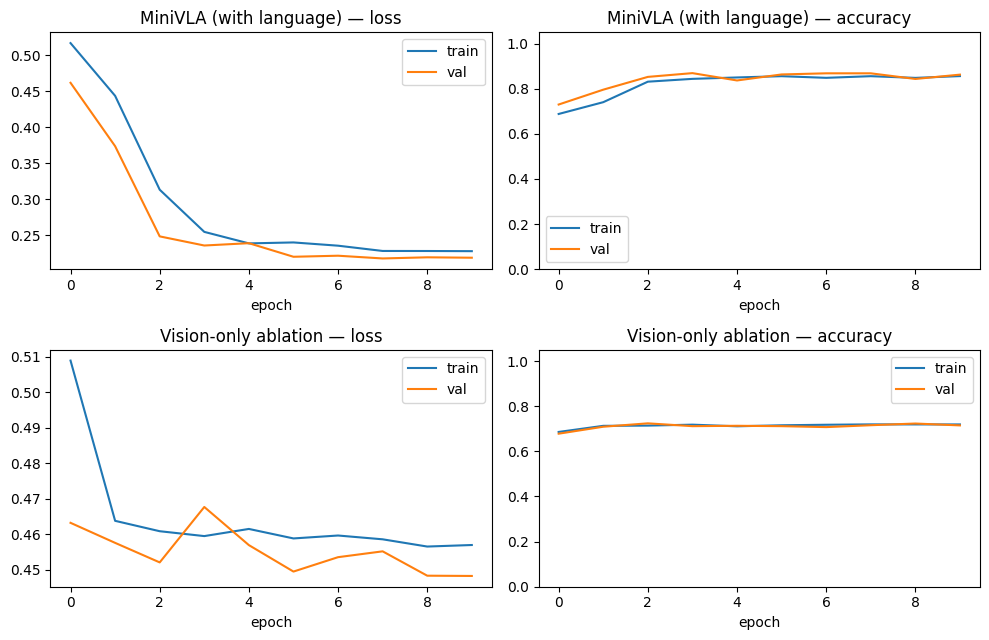

final val accuracy  with language: 0.863   |   vision-only ablation: 0.715


In [19]:
fig, axes= plt.subplots(2, 2, figsize=(10, 6.5))
for ax_row,history, title in [(axes[0], history_full, "MiniVLA (with language)"),
                                (axes[1], history_vo, "Vision-only ablation")]:
    
    ax_row[0].plot(history["train_loss"], label="train")
    ax_row[0].plot(history["val_loss"], label="val")
    
    ax_row[0].set_title(f"{title} — loss"); ax_row[0].set_xlabel("epoch"); ax_row[0].legend()

    ax_row[1].plot(history["train_acc"], label="train")
    ax_row[1].plot(history["val_acc"], label="val")
    ax_row[1].set_title(f"{title} — accuracy"); ax_row[1].set_xlabel("epoch")
    ax_row[1].set_ylim(0, 1.05); ax_row[1].legend()
plt.tight_layout(); plt.show()

print(f"final val accuracy  with language: {history_full['val_acc'][-1]:.3f}"
      f"   |   vision-only ablation: {history_vo['val_acc'][-1]:.3f}")

# evaluation de quantitative

* validation accuracy telling how well each model imitates the expert on held-out *transitions*
* if we drop the trained model into the environment and let it control the cart for a full episode, how long does the pole stay up? THIS IS *closed-loop* performance.

 
**1. random: the environment-agnostic baseline  2. untrained VLA:  same architecture, random weights, no training at all  3. vision-only: trained, ablation  4. full VLA(trained) - vision + language, trained  5. expert: scripted controller used to generate the data(it's the uppeer bound)**


In [21]:
def make_model_selector(model, instruction, device=device): 
    model.eval()
    bow = torch.from_numpy(bow_vector(instruction)). unsqueeze(0).to(device)

    def selector(obs, env):
        img = to_tensor_batch(obs). to(device)
        with torch.no_grad():
            logits = model(img, bow)

        return int(logits. argmax(dim=-1).item())

    return selector

def expert_selector_factory(instruction):
    return lambda obs, env: expert_action(env.theta, env.theta_dot, env.x, instruction)

def random_selector(obs, env):
    return np.random.randint(2)


set_seed(2)
untrained_model= MiniVLA(use_language=True).to(device) #fresh and random weights, never trained

results =[]
for instr in INSTRUCTIONS: 
    policies = [
        ("random", random_selector),
        ("untrained VLA", make_model_selector(untrained_model, instr)),
        ("vision-only(trained)", make_model_selector(vision_only_model, instr)),
        ("full VLA(trained)", make_model_selector(vla_model, instr)),
        ("expert", expert_selector_factory(instr)),
        
    ]

    for name, selector in policies: 
        avg_len, avg_rew = average_performance(
            lambda: MiniCartPoleVisionEnv(max_steps=200), selector, episodes=20
        )
        results.append({"instruction": instr, "policy": name, "avg_survival_steps": avg_len, "avg_reward": avg_rew})

results_df = pd.DataFrame(results)
pivot= results_df.pivot(index="policy", columns= "instruction", values="avg_survival_steps")
pivot= pivot.reindex(["random", "untrained VLA", "vision-only(trained)", "full VLA(trained)", "expert"])
pivot.round(1)

instruction,balance the pole,push the cart left,push the cart right
policy,,,
random,24.7,22.2,21.6
untrained VLA,8.3,8.3,8.3
vision-only(trained),8.2,8.2,8.2
full VLA(trained),104.2,8.3,8.4
expert,200.0,8.3,8.4


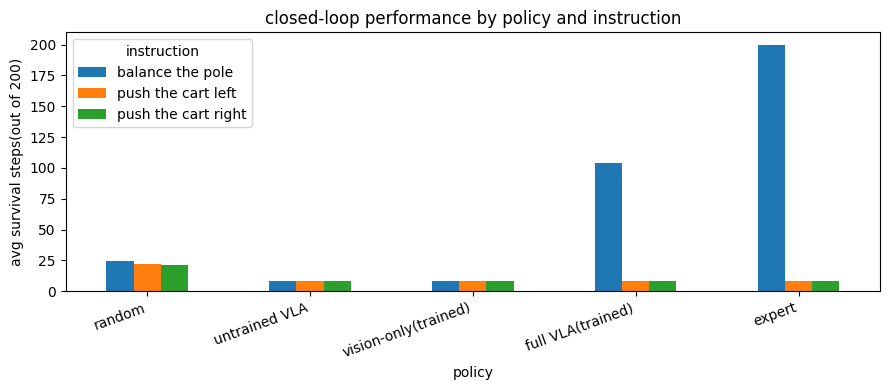

In [22]:
ax = pivot. plot(kind="bar", figsize=(9,4))
ax.set_ylabel("avg survival steps(out of 200)")
ax.set_title("closed-loop performance by policy and instruction")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Using the language, MODEL is the?

two direct checks:
1. does the trained model's action change when only the instruction changes? (for the SAME IMAGE)

2. unseen paraphrases: a hashed bag-of-words has NO any notion of word order or synonyms or even negation, *so it can only generalize to phrasing that resuse the same **words** as training*. `"push the cart right"` and `"don't push the cart right"` hash to nearly the same vector.
    > this is a very WELL KNOWN limitation in VLAs, and this is why they use a proper tokenizer + a pretrained language model instead of hashing/

In [23]:
env = MiniCartPoleVisionEnv()
obs, _ = env.reset(seed=42)

print("same image, THREE different instrucitons: ")
for instr in INSTRUCTIONS:
    action = make_model_selector(vla_model, instr)(obs, env)
    print(f" instruction={instr!r:25s} -> action ={'right' if action ==1 else 'left'}")

same image, THREE different instrucitons: 
 instruction='balance the pole'        -> action =right
 instruction='push the cart right'     -> action =right
 instruction='push the cart left'      -> action =left


In [24]:
paraphrases = {
    "balance the pole": ["please balance the pole", "keep the pole balanced up", "make cart balanced"],
    "push the cart right": ["push cart right now", "quickly push the cart to the right", "cart goes right"],
    "push the cart left": ["push cart left now", "quickly push the cart to the left", "cart goes left"],
}

print("generalization to unseen phrasings: ")
for canonical, variants in paraphrases.items():
    a_canon= make_model_selector(vla_model, canonical)(obs, env)
    for variant in variants:
        a_variant = make_model_selector(vla_model, variant)(obs, env)
        match = "same action" if a_canon == a_variant else "DIFFERENT action"
        print(f" {canonical!r:22s} vs {variant!r:38s}->{match}")

generalization to unseen phrasings: 
 'balance the pole'     vs 'please balance the pole'             ->same action
 'balance the pole'     vs 'keep the pole balanced up'           ->same action
 'balance the pole'     vs 'make cart balanced'                  ->same action
 'push the cart right'  vs 'push cart right now'                 ->same action
 'push the cart right'  vs 'quickly push the cart to the right'  ->same action
 'push the cart right'  vs 'cart goes right'                     ->same action
 'push the cart left'   vs 'push cart left now'                  ->same action
 'push the cart left'   vs 'quickly push the cart to the left'   ->same action
 'push the cart left'   vs 'cart goes left'                      ->same action


# A rollout, Visualized, at nearest screens, NEAR YOU :)
a film of sampled frames from ONE episode, plus an animated GIF, that shows the observation and the model's action probabilities, step by step.

instruction: "balance the pole" -> episode survived 63 / 200 steps


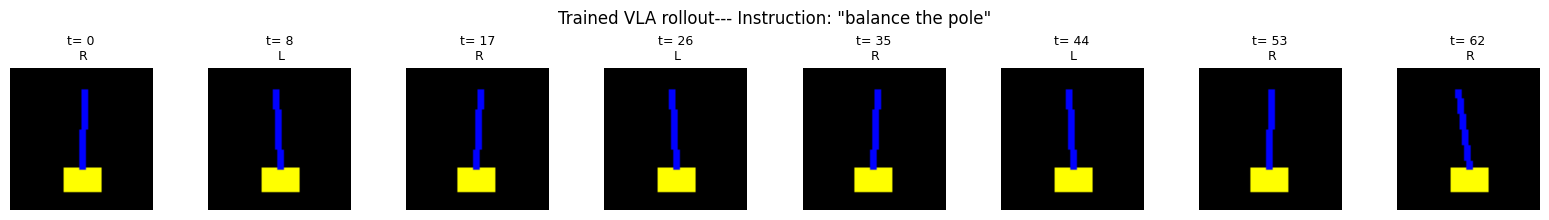

In [31]:
def rollout_with_probs(model, instruction, env, max_steps=200, seed=None, device=device):
    model.eval()
    bow= torch.from_numpy(bow_vector(instruction)).unsqueeze(0).to(device)

    obs, _ = env.reset(seed=seed)
    frames, probs_hist, actions_hist = [], [], []

    for t in range(max_steps):
        img= to_tensor_batch(obs).to(device)
        with torch.no_grad():
            probs = torch. softmax(model(img, bow), dim =-1).squeeze(0).cpu().numpy()
        
        action = int(probs.argmax())
        frames.append(obs)
        probs_hist.append(probs)
        actions_hist.append(action)

        obs, r, terminated, truncated, _ = env. step(action)
        if terminated or truncated: 
            break
    return frames, probs_hist, actions_hist


env= MiniCartPoleVisionEnv(max_steps=200)
frames, probs_hist, actions_hist = rollout_with_probs(vla_model, "balance the pole", env, seed=7)
print(f'instruction: "balance the pole" -> episode survived {len(frames)} / 200 steps')


n_show= min(8, len(frames))
idxs = np.linspace(0, len(frames) - 1, n_show).astype(int)
fig, axes = plt. subplots(1, n_show, figsize = (2*n_show, 2.2))
for ax, i in zip(axes, idxs):
    ax.imshow(frames[i]); ax.axis("off")
    ax.set_title(f"t= {i}\n {'R' if actions_hist[i]==1 else 'L'}", fontsize=9)

plt.suptitle('Trained VLA rollout--- Instruction: "balance the pole"')
plt.tight_layout(); plt.show()


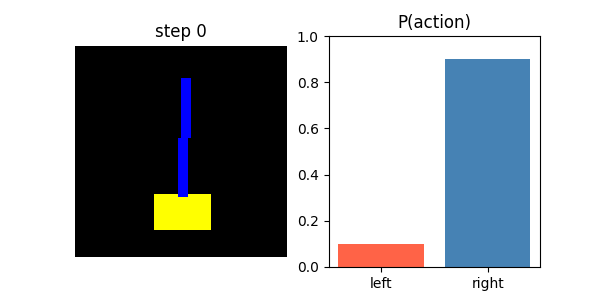

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
im = ax1.imshow(frames[0]); ax1.axis("off")
bars = ax2.bar(["left", "right"], probs_hist[0], color=["tomato", "steelblue"])
ax2.set_ylim(0, 1); ax2.set_title("P(action)")


def update(i):
    im.set_data(frames[i])
    for bar, h in zip(bars, probs_hist[i]):
        bar.set_height(h)
    ax1.set_title(f"step {i}")
    return [im, *bars]

ani = animation.FuncAnimation(fig,update, frames= len(frames), interval=120, blit=False)
ani.save("mini_vla_rollout.gif", writer= animation.PillowWriter(fps=8))
plt.close(fig)

display(IPyImage(filename="mini_vla_rollout.gif"))

In [33]:
torch.save({
    "model_state_dict": vla_model.state_dict(),
    "use_language": True,
    "instructions": INSTRUCTIONS,
}, "mini_vla_trained.pt")
print("saved checkpoint to mini_vla_trained.pt")

# reload into a fresh model to confirm the checkpoint round-trips correctly
checkpoint = torch.load("mini_vla_trained.pt", map_location=device)
reloaded_model = MiniVLA(use_language=checkpoint["use_language"]).to(device)
reloaded_model.load_state_dict(checkpoint["model_state_dict"])
reloaded_model.eval()
print("checkpoint reloaded successfully; instructions:", checkpoint["instructions"])

saved checkpoint to mini_vla_trained.pt
checkpoint reloaded successfully; instructions: ['balance the pole', 'push the cart right', 'push the cart left']
